In [1]:
# ============================================================
# CELL 1 — Imports and load the cleaned dataset
# We start fresh in a new notebook, so we re-import everything
# and load the cleaned CSV we exported earlier — not the raw one
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

# Load the CLEANED dataset, not the raw one
df = pd.read_csv('../data/cleaned/startup_funding_cleaned.csv')

# Convert date column back to datetime
# CSV files don't preserve datetime type, so we redo this
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded cleaned dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(3)

Loaded cleaned dataset: 2059 rows x 10 columns


,date,startup_name,industry,sub_vertical,city,investors,investment_type,amount_usd,year,month
0,2020-01-09,BYJUâS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity,200000000.0,2020.0,1.0
1,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurugram,Susquehanna Growth Equity,Series C,8048394.0,2020.0,1.0
2,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0,2020.0,1.0


Total funding by year (in USD Billion):
     year    amount_usd  amount_billion
0  2015.0  8.597207e+09        8.597207
1  2016.0  3.828089e+09        3.828089
2  2017.0  1.042931e+10       10.429310
3  2018.0  5.116118e+09        5.116118
4  2019.0  9.686577e+09        9.686577
5  2020.0  3.902073e+08        0.390207


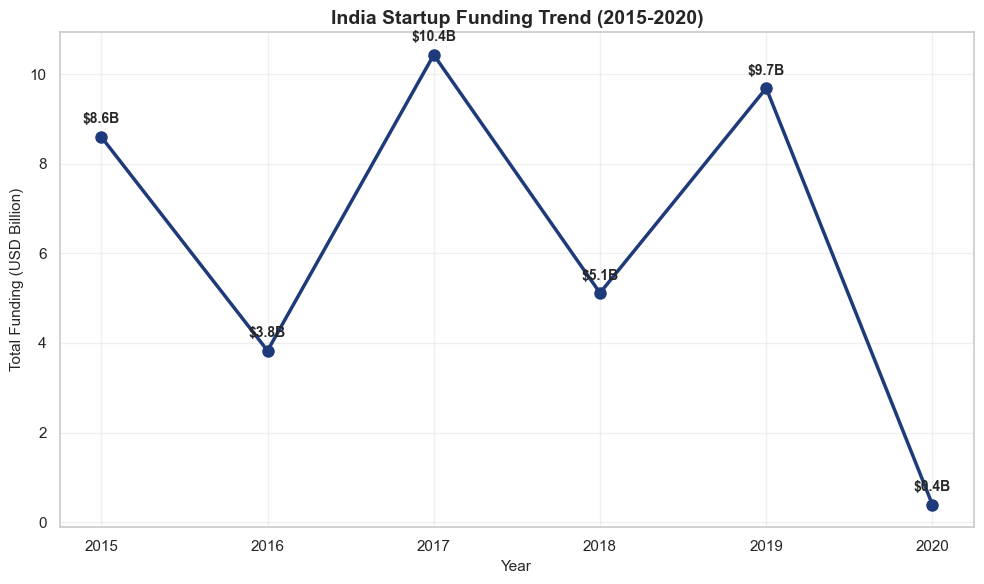

In [2]:
# ============================================================
# CELL 2 — Year-wise total funding trend
# We group all funding by year and sum the amounts
# Then plot it as a line chart to show growth over time
# This is the single most important chart for the project
# ============================================================

# Group data by year and sum the funding amount
yearly_funding = df.groupby('year')['amount_usd'].sum().reset_index()

# Convert amount to billions for readability on the chart
yearly_funding['amount_billion'] = yearly_funding['amount_usd'] / 1e9

print("Total funding by year (in USD Billion):")
print(yearly_funding)

# Create the line chart
plt.figure(figsize=(10, 6))
plt.plot(
    yearly_funding['year'],
    yearly_funding['amount_billion'],
    marker='o',
    linewidth=2.5,
    color='#1F3A7A',
    markersize=8
)

# Add data labels on each point

for x, y in zip(yearly_funding['year'], yearly_funding['amount_billion']):
    plt.text(x, y + 0.3, f'${y:.1f}B', ha='center', fontsize=10, fontweight='bold')

plt.title('India Startup Funding Trend (2015-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Total Funding (USD Billion)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the chart for later use in PPT/report
plt.savefig('../reports/chart_yearly_funding_trend.png', dpi=150)
plt.show()

Top 10 sectors by total funding (USD Billion):
industry
Consumer Internet     6.246834
eCommerce             5.002533
Transportation        3.916632
Technology            2.229708
Finance               1.971438
ECommerce             1.878798
Unknown               1.230961
FinTech               1.220711
E-Commerce            1.008110
Online Marketplace    0.700143
Name: amount_usd, dtype: float64


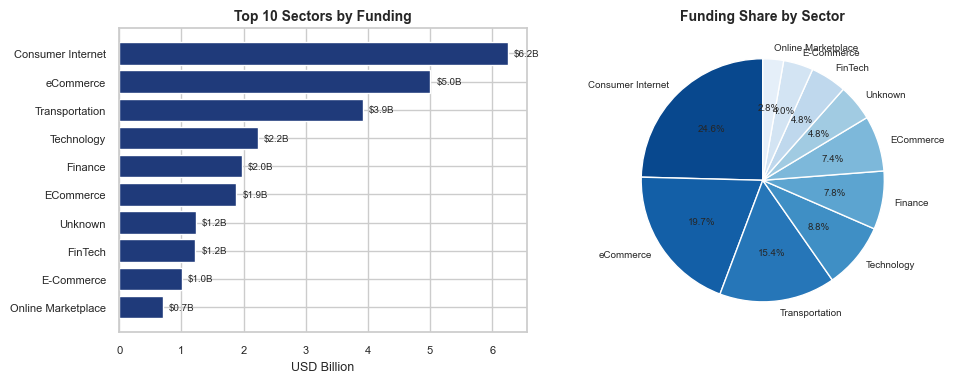

In [3]:
# ============================================================
# CELL 3 — Sector-wise funding breakdown
# We find the top 10 industries by total funding received
# Two charts: a bar chart (amounts) and a pie chart (share %)
# ============================================================

# Group by industry, sum funding, sort descending, take top 10
sector_funding = df.groupby('industry')['amount_usd'].sum().sort_values(ascending=False).head(10)
sector_funding_billion = sector_funding / 1e9

print("Top 10 sectors by total funding (USD Billion):")
print(sector_funding_billion)

# Create a figure with two subplots side by side - smaller size
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- LEFT CHART: Horizontal bar chart ---
axes[0].barh(
    sector_funding_billion.index[::-1],   # reverse so highest is on top
    sector_funding_billion.values[::-1],
    color='#1F3A7A'
)
axes[0].set_title('Top 10 Sectors by Funding', fontsize=10, fontweight='bold')
axes[0].set_xlabel('USD Billion', fontsize=9)
axes[0].tick_params(axis='both', labelsize=8)

# Add value labels on bars
for i, v in enumerate(sector_funding_billion.values[::-1]):
    axes[0].text(v + 0.1, i, f'${v:.1f}B', va='center', fontsize=7)

# --- RIGHT CHART: Pie chart showing share ---
axes[1].pie(
    sector_funding_billion.values,
    labels=sector_funding_billion.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 7},
    colors=sns.color_palette('Blues_r', len(sector_funding_billion))
)
axes[1].set_title('Funding Share by Sector', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/chart_sector_funding.png', dpi=150)
plt.show()

In [4]:
# ============================================================
# CELL 4 — Fix industry name duplicates
# eCommerce, ECommerce, E-Commerce are the same sector
# written differently — we merge them into one clean name
# ============================================================

# See all unique industry names first
print("Sample of industry values that need merging:")
print(df['industry'].value_counts().head(20))

Sample of industry values that need merging:
industry
Consumer Internet       588
Technology              310
Unknown                 129
eCommerce               126
Finance                  57
Healthcare               44
ECommerce                37
E-Commerce               26
Logistics                23
Education                19
Food & Beverage          15
Ed-Tech                  12
FinTech                   9
IT                        8
E-commerce                8
Fin-Tech                  6
Online Food Delivery      5
Health and Wellness       5
Ecommerce                 5
Food and Beverage         5
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 5 — Standardize industry names
# Same sector written in many ways - merge into one clean name
# eg. eCommerce, ECommerce, E-Commerce, E-commerce, Ecommerce
# ============================================================

# Strip extra spaces first
df['industry'] = df['industry'].str.strip()

# Mapping of all variations to one standard name
industry_mapping = {
    # E-commerce variations
    'eCommerce'              : 'E-Commerce',
    'ECommerce'               : 'E-Commerce',
    'E-commerce'              : 'E-Commerce',
    'Ecommerce'               : 'E-Commerce',

    # FinTech variations
    'FinTech'                 : 'FinTech',
    'Fin-Tech'                : 'FinTech',
    'Finance'                 : 'FinTech',

    # EdTech variations
    'Ed-Tech'                 : 'EdTech',
    'Education'               : 'EdTech',

    # Food variations
    'Food & Beverage'         : 'Food and Beverage',
    'Online Food Delivery'    : 'Food and Beverage',

    # Healthcare variations
    'Health and Wellness'     : 'Healthcare',
    'HealthTech'              : 'Healthcare',

    # Tech catch-all
    'IT'                      : 'Technology',
}

df['industry'] = df['industry'].map(industry_mapping).fillna(df['industry'])

# Confirm result
print("Top 15 industries after standardization:")
print(df['industry'].value_counts().head(15))
print(f"\nUnique industries now: {df['industry'].nunique()}")

Top 15 industries after standardization:
industry
Consumer Internet                588
Technology                       318
E-Commerce                       202
Unknown                          129
FinTech                           72
Healthcare                        49
EdTech                            34
Food and Beverage                 25
Logistics                         23
Others                             4
Transportation                     4
Food and Beverages                 3
Food                               3
Social Media                       3
Big Data & Analytics platform      3
Name: count, dtype: int64

Unique industries now: 571


Top 10 sectors by total funding (USD Billion) - CLEANED:
industry
E-Commerce                          8.244314
Consumer Internet                   6.246834
Transportation                      3.916632
FinTech                             3.332849
Technology                          2.263588
Unknown                             1.230961
Healthcare                          0.871418
Online Marketplace                  0.700143
E-Commerce & M-Commerce platform    0.680000
B2B                                 0.587000
Name: amount_usd, dtype: float64


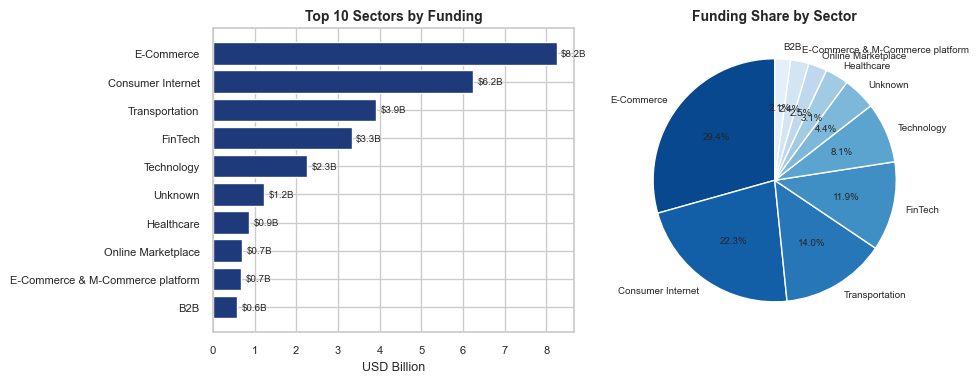

In [6]:
# ============================================================
# CELL 6 — Re-run sector-wise funding breakdown
# Same code as before, but now using cleaned industry names
# This overwrites our earlier chart with the correct version
# ============================================================

sector_funding = df.groupby('industry')['amount_usd'].sum().sort_values(ascending=False).head(10)
sector_funding_billion = sector_funding / 1e9

print("Top 10 sectors by total funding (USD Billion) - CLEANED:")
print(sector_funding_billion)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].barh(
    sector_funding_billion.index[::-1],
    sector_funding_billion.values[::-1],
    color='#1F3A7A'
)
axes[0].set_title('Top 10 Sectors by Funding', fontsize=10, fontweight='bold')
axes[0].set_xlabel('USD Billion', fontsize=9)
axes[0].tick_params(axis='both', labelsize=8)

for i, v in enumerate(sector_funding_billion.values[::-1]):
    axes[0].text(v + 0.1, i, f'${v:.1f}B', va='center', fontsize=7)

axes[1].pie(
    sector_funding_billion.values,
    labels=sector_funding_billion.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 7},
    colors=sns.color_palette('Blues_r', len(sector_funding_billion))
)
axes[1].set_title('Funding Share by Sector', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/chart_sector_funding.png', dpi=150)
plt.show()

Top 10 cities by number of startups:
city
Bengaluru    582
Mumbai       397
Delhi        266
Gurugram     241
Unknown      133
Chennai       75
Hyderabad     72
Pune          71
Noida         55
Ahmedabad     27
Name: count, dtype: int64


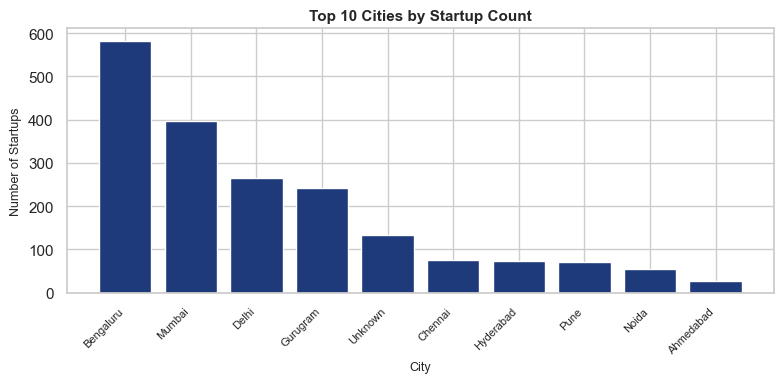

In [7]:
# ============================================================
# CELL 7 — City-wise distribution
# Simple bar chart showing which cities have the most startups
# ============================================================

# Count startups per city, get top 10
city_counts = df['city'].value_counts().head(10)

print("Top 10 cities by number of startups:")
print(city_counts)

# Simple bar chart
plt.figure(figsize=(8, 4))
plt.bar(city_counts.index, city_counts.values, color='#1F3A7A')
plt.title('Top 10 Cities by Startup Count', fontsize=11, fontweight='bold')
plt.xlabel('City', fontsize=9)
plt.ylabel('Number of Startups', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

plt.savefig('../reports/chart_city_distribution.png', dpi=150)
plt.show()

Number of deals by funding stage:
investment_type
Private Equity    1074
Seed               745
Seed/Angel         110
Debt                25
Series A            22
Series B            20
Series C            14
Series D            12
Name: count, dtype: int64


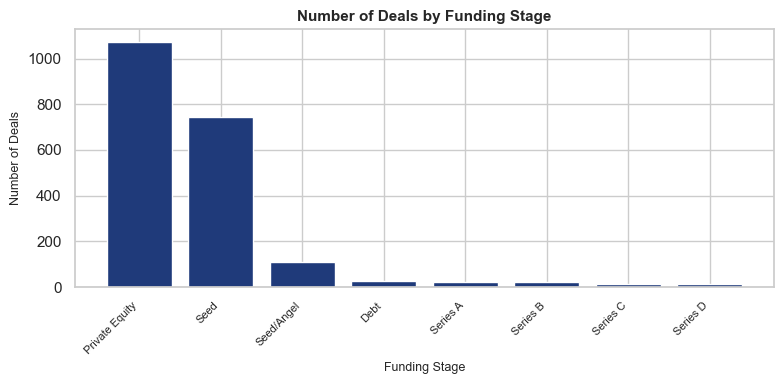

In [8]:
# ============================================================
# CELL 8 — Funding stage distribution
# Shows how many startups got each type of funding round
# and the average deal size for each stage
# ============================================================

# Count deals by investment type, get top 8 (ignore rare ones)
stage_counts = df['investment_type'].value_counts().head(8)

print("Number of deals by funding stage:")
print(stage_counts)

# Simple bar chart
plt.figure(figsize=(8, 4))
plt.bar(stage_counts.index, stage_counts.values, color='#1F3A7A')
plt.title('Number of Deals by Funding Stage', fontsize=11, fontweight='bold')
plt.xlabel('Funding Stage', fontsize=9)
plt.ylabel('Number of Deals', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

plt.savefig('../reports/chart_funding_stages.png', dpi=150)
plt.show()

Average funding amount by stage (USD Million):
investment_type
Private Equity     25.416339
Seed                1.107189
Seed/Angel          2.051782
Debt                6.380814
Series A            9.236364
Series B          239.959787
Series C           74.622742
Series D          123.483250
Name: amount_usd, dtype: float64


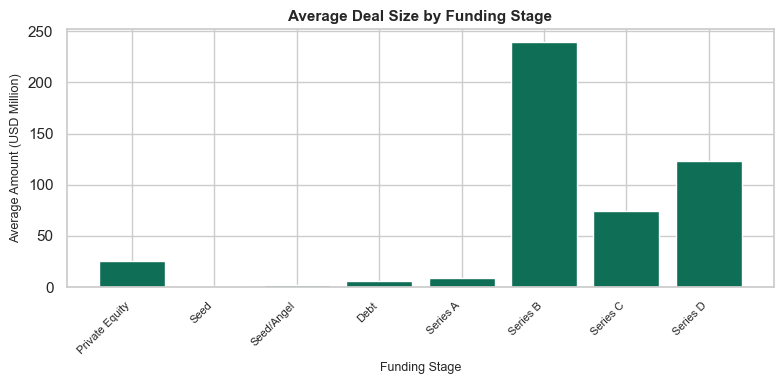

In [9]:
# ============================================================
# CELL 9 — Average deal size per funding stage
# Shows the average amount of money raised at each stage
# Helps understand stage economics, not just deal count
# ============================================================

# Calculate average funding amount per stage, for the same top 8 stages
avg_by_stage = df[df['investment_type'].isin(stage_counts.index)].groupby('investment_type')['amount_usd'].mean()
avg_by_stage = avg_by_stage.reindex(stage_counts.index)  # keep same order as deal count chart
avg_by_stage_million = avg_by_stage / 1e6

print("Average funding amount by stage (USD Million):")
print(avg_by_stage_million)

# Simple bar chart
plt.figure(figsize=(8, 4))
plt.bar(avg_by_stage_million.index, avg_by_stage_million.values, color='#0F6E56')
plt.title('Average Deal Size by Funding Stage', fontsize=11, fontweight='bold')
plt.xlabel('Funding Stage', fontsize=9)
plt.ylabel('Average Amount (USD Million)', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

plt.savefig('../reports/chart_avg_deal_size.png', dpi=150)
plt.show()

Top 10 investors by number of deals:
investors
Sequoia Capital           68
Accel Partners            58
SAIF Partners             47
Kalaari Capital           47
                          36
Blume Ventures            35
Undisclosed Investors     29
Nexus Venture Partners    27
Tiger Global              27
IDG Ventures              25
Name: count, dtype: int64


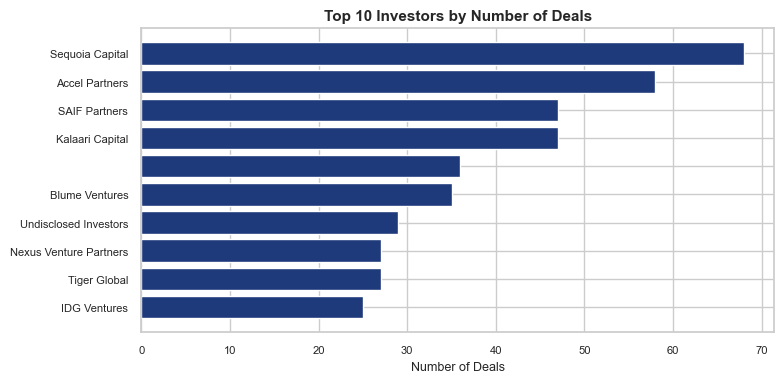

In [10]:
# ============================================================
# CELL 10 — Top investors analysis
# The investors column has multiple investors per row
# separated by commas eg. "Sequoia, Tiger Global, Accel"
# We split them, count each investor individually
# ============================================================

# Split investors column by comma and explode into individual rows
# This turns "Sequoia, Tiger Global" into two separate rows
investor_series = df['investors'].str.split(',').explode()

# Strip spaces and remove 'Unknown'
investor_series = investor_series.str.strip()
investor_series = investor_series[investor_series != 'Unknown']

# Count top 10 investors by number of deals
top_investors = investor_series.value_counts().head(10)

print("Top 10 investors by number of deals:")
print(top_investors)

# Simple horizontal bar chart
plt.figure(figsize=(8, 4))
plt.barh(top_investors.index[::-1], top_investors.values[::-1], color='#1F3A7A')
plt.title('Top 10 Investors by Number of Deals', fontsize=11, fontweight='bold')
plt.xlabel('Number of Deals', fontsize=9)
plt.tick_params(axis='both', labelsize=8)
plt.tight_layout()

plt.savefig('../reports/chart_top_investors.png', dpi=150)
plt.show()

Year-over-year funding growth rate (%):
year
2015.0      NaN
2016.0    -55.5
2017.0    172.4
2018.0    -50.9
2019.0     89.3
2020.0    -96.0
Name: amount_usd, dtype: float64


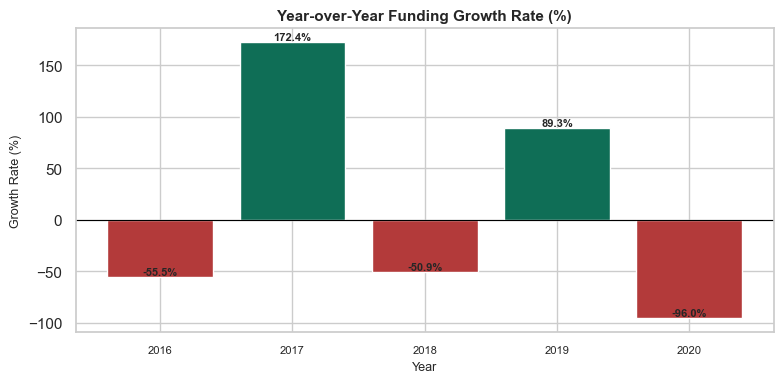

In [11]:
# ============================================================
# CELL 11 — Year over year funding growth rate
# We calculate how much funding grew or fell each year
# compared to the previous year (in percentage)
# ============================================================

# Get total funding per year
yearly = df.groupby('year')['amount_usd'].sum()

# Calculate % change from previous year
yoy_growth = yearly.pct_change() * 100

print("Year-over-year funding growth rate (%):")
print(yoy_growth.round(1))

# Bar chart with color — green for growth, red for decline
colors = ['#0F6E56' if v >= 0 else '#B33A3A' for v in yoy_growth.values]

plt.figure(figsize=(8, 4))
plt.bar(yoy_growth.index, yoy_growth.values, color=colors)
plt.axhline(y=0, color='black', linewidth=0.8)  # zero line
plt.title('Year-over-Year Funding Growth Rate (%)', fontsize=11, fontweight='bold')
plt.xlabel('Year', fontsize=9)
plt.ylabel('Growth Rate (%)', fontsize=9)
plt.xticks(fontsize=8)

# Add value labels on bars
for x, y in zip(yoy_growth.index, yoy_growth.values):
    plt.text(x, y + 2, f'{y:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/chart_yoy_growth.png', dpi=150)
plt.show()